In [2]:
import pandas as pd

In [3]:

df = pd.read_csv("Teen_Mental_Health_Dataset.csv")
display(df.head())
df.info()
display(df.describe())
df.shape

,age,gender,daily_social_media_hours,platform_usage,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,social_interaction_level,stress_level,anxiety_level,addiction_level,depression_label
0,14,male,7.9,Instagram,7.4,2.9,3.01,1.5,low,2,2,1,0
1,19,female,1.9,TikTok,8.0,2.9,3.22,0.8,high,8,1,10,0
2,17,female,1.3,Instagram,7.6,0.5,3.92,0.0,high,2,4,2,0
3,15,male,7.4,TikTok,6.9,1.6,3.48,0.8,medium,1,7,9,0
4,15,female,4.7,Both,4.9,3.0,2.37,1.4,medium,3,5,2,0


<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 13 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   age                       1200 non-null   int64  
 1   gender                    1200 non-null   str    
 2   daily_social_media_hours  1200 non-null   float64
 3   platform_usage            1200 non-null   str    
 4   sleep_hours               1200 non-null   float64
 5   screen_time_before_sleep  1200 non-null   float64
 6   academic_performance      1200 non-null   float64
 7   physical_activity         1200 non-null   float64
 8   social_interaction_level  1200 non-null   str    
 9   stress_level              1200 non-null   int64  
 10  anxiety_level             1200 non-null   int64  
 11  addiction_level           1200 non-null   int64  
 12  depression_label          1200 non-null   int64  
dtypes: float64(5), int64(5), str(3)
memory usage: 122.0 KB


,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,depression_label
count,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000,1200.000000
mean,15.928333,4.536667,6.449417,1.740333,2.990383,1.014500,5.445833,5.636667,5.565000,0.025833
std,2.021947,2.029599,1.442677,0.716660,0.576758,0.582185,2.903290,2.859453,2.830627,0.158704
min,13.000000,1.000000,4.000000,0.500000,2.000000,0.000000,1.000000,1.000000,1.000000,0.000000
25%,14.000000,2.800000,5.200000,1.100000,2.500000,0.500000,3.000000,3.000000,3.000000,0.000000
50%,16.000000,4.500000,6.500000,1.800000,2.990000,1.000000,5.000000,6.000000,6.000000,0.000000
75%,18.000000,6.300000,7.600000,2.400000,3.480000,1.500000,8.000000,8.000000,8.000000,0.000000
max,19.000000,8.000000,9.000000,3.000000,4.000000,2.000000,10.000000,10.000000,10.000000,1.000000


(1200, 13)

In [4]:
df.isnull().sum()

age                         0
gender                      0
daily_social_media_hours    0
platform_usage              0
sleep_hours                 0
screen_time_before_sleep    0
academic_performance        0
physical_activity           0
social_interaction_level    0
stress_level                0
anxiety_level               0
addiction_level             0
depression_label            0
dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

depression_label
0    1169
1      31
Name: count, dtype: int64

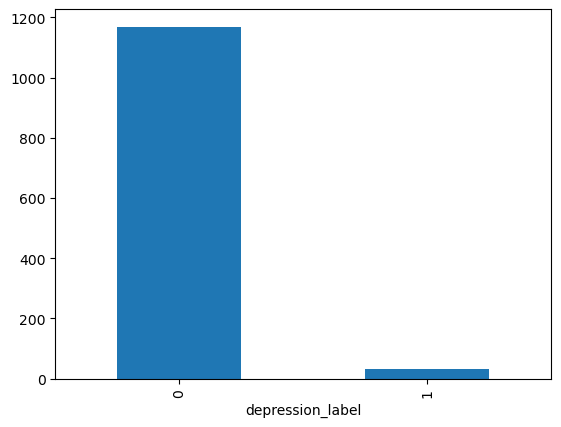

In [5]:
df['depression_label'].value_counts()
counts = df['depression_label'].value_counts()
counts.plot.bar()
counts

The dataset is severely imbalanced, with the positive class (depression_label=1) representing only 2.6% of samples. This limits the usefulness of accuracy as an evaluation metric, motivating our choice of F1 and ROC-AUC, and requires the use of stratified sampling and class-weighted models.

In [6]:
X = df.drop(columns=['depression_label'])   # 拿掉答案那欄,剩下都是線索
y = df['depression_label']                  # 只挑「答案」那欄
X.shape, y.shape                             # 確認形狀

((1200, 12), (1200,))

In [7]:
X = pd.get_dummies(X, drop_first=True, dtype=int)
X.head()

,age,daily_social_media_hours,sleep_hours,screen_time_before_sleep,academic_performance,physical_activity,stress_level,anxiety_level,addiction_level,gender_male,platform_usage_Instagram,platform_usage_TikTok,social_interaction_level_low,social_interaction_level_medium
0,14,7.9,7.4,2.9,3.01,1.5,2,2,1,1,1,0,1,0
1,19,1.9,8.0,2.9,3.22,0.8,8,1,10,0,0,1,0,0
2,17,1.3,7.6,0.5,3.92,0.0,2,4,2,0,1,0,0,0
3,15,7.4,6.9,1.6,3.48,0.8,1,7,9,1,0,1,0,1
4,15,4.7,4.9,3.0,2.37,1.4,3,5,2,0,0,0,0,1


In [8]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
X_train.shape, X_test.shape

((960, 14), (240, 14))

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)   # 只用 train 學 mean/std,再套用
X_test  = scaler.transform(X_test)        # 用 train 的 mean/std 套到 test

X_train.shape, X_test.shape

((960, 14), (240, 14))

## Model 1: Random Forest (Baseline)

Random Forest is an ensemble of decision trees trained on bootstrapped samples with random feature subsets at each split. We start with it because:

- **Robust to imbalanced data** when using `class_weight='balanced'`
- **No scaling required** (tree-based), so it's a good sanity check
- **Provides `feature_importances_`** — useful later for the feature-removal experiment
- **Handles non-linear interactions** between features (e.g. high screen time × low sleep)

Since the positive class is only 2.6%, we report **F1** and **ROC-AUC** instead of accuracy.

In [12]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, f1_score

# Baseline Random Forest — default hyperparameters, balanced class weights
rf_base = RandomForestClassifier(
    random_state=42,
    class_weight='balanced'   # 處理 2.6% positive 的不平衡 / handle class imbalance
)
rf_base.fit(X_train, y_train)

# Predictions on the held-out test set
y_pred  = rf_base.predict(X_test)
y_proba = rf_base.predict_proba(X_test)[:, 1]   # probability of class=1, for ROC-AUC

print("=== Random Forest (Baseline) ===")
print(classification_report(y_test, y_pred, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred))
print(f"\nF1 (positive class): {f1_score(y_test, y_pred):.4f}")
print(f"ROC-AUC            : {roc_auc_score(y_test, y_proba):.4f}")

=== Random Forest (Baseline) ===
              precision    recall  f1-score   support

           0     0.9791    1.0000    0.9894       234
           1     1.0000    0.1667    0.2857         6

    accuracy                         0.9792       240
   macro avg     0.9895    0.5833    0.6376       240
weighted avg     0.9796    0.9792    0.9718       240

Confusion matrix:
[[234   0]
 [  5   1]]

F1 (positive class): 0.2857
ROC-AUC            : 1.0000


### Random Forest — GridSearchCV tuning

We tune Random Forest with 5-fold **stratified** cross-validation, scoring on **ROC-AUC** (threshold-independent and robust to class imbalance). The grid covers tree count, depth, split/leaf size, and feature subsampling — a total of 48 combinations.

In [13]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

# Hyperparameter grid
rf_param_grid = {
    'n_estimators':      [100, 300],
    'max_depth':         [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf':  [1, 2],
    'max_features':      ['sqrt', 'log2'],
}

# Stratified 5-fold keeps the 2.6% positive ratio in every fold
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42, class_weight='balanced', n_jobs=-1),
    param_grid=rf_param_grid,
    scoring='roc_auc',     # threshold-independent, good for imbalanced data
    cv=cv,
    n_jobs=-1,             # use all CPU cores
    verbose=1,
    refit=True,            # automatically refit the best model on all training data
)

rf_grid.fit(X_train, y_train)

print(f"Best ROC-AUC (CV): {rf_grid.best_score_:.4f}")
print(f"Best params: {rf_grid.best_params_}")

Fitting 5 folds for each of 48 candidates, totalling 240 fits
Best ROC-AUC (CV): 0.9999
Best params: {'max_depth': None, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 100}


In [14]:
import numpy as np
import pandas as pd

# Best model from GridSearchCV (already refit on full training data)
rf_best = rf_grid.best_estimator_

# Evaluate on the held-out test set
y_pred_t  = rf_best.predict(X_test)
y_proba_t = rf_best.predict_proba(X_test)[:, 1]

print("=== Random Forest (Tuned) — Test set ===")
print(classification_report(y_test, y_pred_t, digits=4))
print("Confusion matrix:")
print(confusion_matrix(y_test, y_pred_t))
print(f"\nF1 (positive class): {f1_score(y_test, y_pred_t):.4f}")
print(f"ROC-AUC            : {roc_auc_score(y_test, y_proba_t):.4f}")

# Feature importances — will guide the feature-removal experiment later
feature_names = pd.get_dummies(
    df.drop(columns=['depression_label']), drop_first=True, dtype=int
).columns

importances = pd.Series(rf_best.feature_importances_, index=feature_names) \
                .sort_values(ascending=False)

print("\nFeature importances (sorted):")
print(importances.round(4))


=== Random Forest (Tuned) — Test set ===
              precision    recall  f1-score   support

           0     0.9791    1.0000    0.9894       234
           1     1.0000    0.1667    0.2857         6

    accuracy                         0.9792       240
   macro avg     0.9895    0.5833    0.6376       240
weighted avg     0.9796    0.9792    0.9718       240

Confusion matrix:
[[234   0]
 [  5   1]]

F1 (positive class): 0.2857
ROC-AUC            : 1.0000

Feature importances (sorted):
sleep_hours                        0.2465
stress_level                       0.2313
daily_social_media_hours           0.1925
anxiety_level                      0.1880
academic_performance               0.0366
physical_activity                  0.0242
addiction_level                    0.0227
screen_time_before_sleep           0.0226
age                                0.0123
gender_male                        0.0084
social_interaction_level_low       0.0052
platform_usage_Instagram           0.0038